## Alongshore gradients
Away from the equatorial band where the dynamics are modified, the transport into the western boundary region through the interval $[s, s+ds]$ is given by:
$$
dT_\perp = H\mathbf{u}\cdot\hat{n}\,ds = \frac{g'H}{f}\hat{t}\cdot\nabla h\big|_{x=x_b}\,ds = \frac{g'H}{f}\frac{\partial h_b(t,y)}{\partial y}\,ds.
$$
To introduce the equatorial part, we can make use of the fact that $c = \frac{\beta g'H}{f^2} \implies \frac{g'H}{f} = c\frac{f}{\beta}$ to obtain:
$$
dT_\perp = c\frac{f}{\beta}\frac{\partial h_b(t,y)}{\partial y}\,ds
$$
everywhere.
Then, this can be integrated along the entirety of the western boundary region to obtain the transport into the western boundary region just as a function of time:
$$
T_\perp = \int_{y_S}^{y_N} c\frac{f}{\beta}\frac{\partial h_b(t,y)}{\partial y}\sqrt{1+x_b'(y)^2}\,dy
$$

In [22]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from moc_adjustment_theory import EARTH_RADIUS_M, EARTH_ROTATION_S, rossby_speed

output_ds = xr.open_dataset("/Users/awatford/Documents/GitHub/MOCAdjustmentTheory/data/untracked/model_output/global_rossby_model_solution.zarr")
isobath_ds = xr.open_dataset(output_ds.isobath)

In [23]:
h_b = output_ds.h_b.compute()
latitude_rad = np.radians(output_ds.latitude)
g = output_ds.attrs["g_prime_m_s-2"]
H = isobath_ds.attrs["isobath_depth_m"]
f = 2 * EARTH_ROTATION_S * np.sin(latitude_rad)
beta = 2 * EARTH_ROTATION_S * np.cos(latitude_rad) / EARTH_RADIUS_M
c = rossby_speed(output_ds.latitude, g, H)

In [24]:
western_boundaries = {
    "north_atlantic": "x_wA",
    "north_indian": "x_wI",
    "north_pacific": "x_wP",
    "atlantic_indian": "x_wA",
    "atlantic_pacific": "x_wA",
}

T_perp_by_region = []
for region, boundary in western_boundaries.items():
    h_bj = h_b.sel(region=region).dropna("latitude")
    dh_bj_dy = h_bj.differentiate("latitude") * 180 / (np.pi * EARTH_RADIUS_M)
    x_bj = isobath_ds[boundary].interp(latitude=h_bj.latitude)
    x_bj_prime = x_bj.differentiate("latitude") * np.cos(np.radians(h_bj.latitude))
    metric = np.sqrt(1 + x_bj_prime**2)
    integrand = (c * f / beta).sel(latitude=h_bj.latitude) * dh_bj_dy * metric
    T_perp_j = integrand.integrate("latitude") * EARTH_RADIUS_M * np.pi / 180 / 1e6
    T_perp_by_region.append(T_perp_j)

T_perp = xr.concat(T_perp_by_region, dim=output_ds.region)
T_perp.name = "T_perp"
T_perp.attrs["units"] = "Sv"

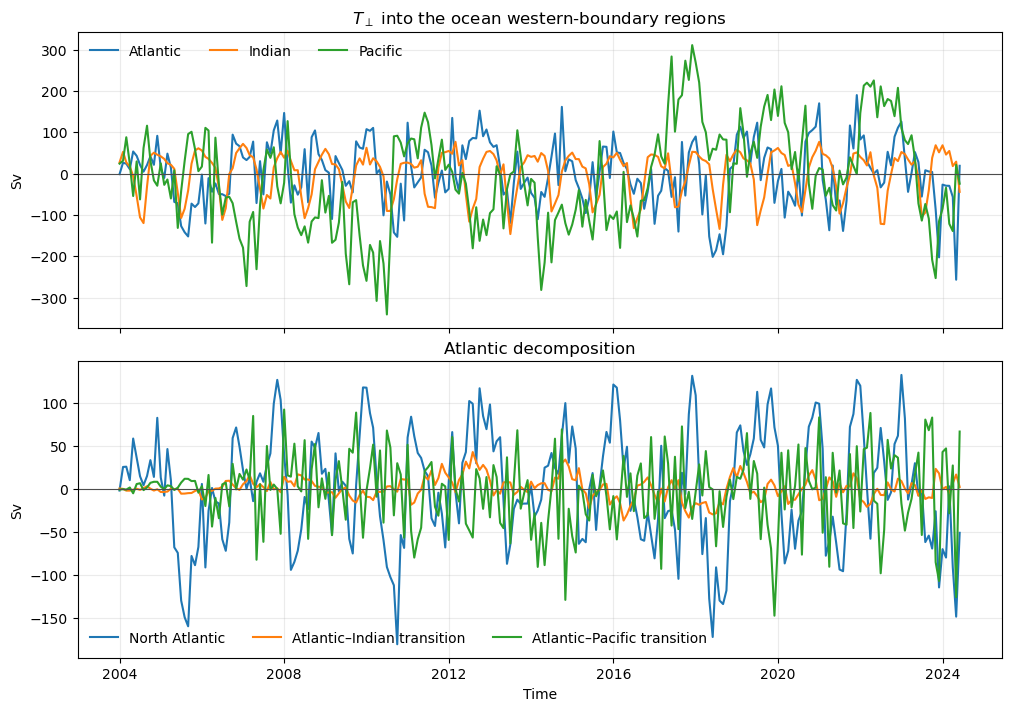

In [25]:
atlantic_regions = ["north_atlantic", "atlantic_indian", "atlantic_pacific"]
T_perp_ocean = xr.concat(
    [
        T_perp.sel(region=atlantic_regions).sum("region"),
        T_perp.sel(region="north_indian", drop=True),
        T_perp.sel(region="north_pacific", drop=True),
    ],
    dim=xr.IndexVariable("ocean", ["Atlantic", "Indian", "Pacific"]),
)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
for ocean in T_perp_ocean.ocean.values:
    T_perp_ocean.sel(ocean=ocean).plot(ax=axes[0], label=ocean)

component_labels = {
    "north_atlantic": "North Atlantic",
    "atlantic_indian": "Atlantic–Indian transition",
    "atlantic_pacific": "Atlantic–Pacific transition",
}
for region, label in component_labels.items():
    T_perp.sel(region=region).plot(ax=axes[1], label=label)

axes[0].set(title=r"$T_\perp$ into the ocean western-boundary regions", xlabel="", ylabel="Sv")
axes[1].set(title="Atlantic decomposition", xlabel="Time", ylabel="Sv")
for ax in axes:
    ax.axhline(0, color="0.3", linewidth=0.8)
    ax.grid(alpha=0.25)
    ax.legend(ncol=3, frameon=False)

## Conclusion
While this was a good exercise, I'm not convinced that this is actually meaningful or relevant.
The question arose from a misunderstanding of what the theory's governing equations actually are.
They are not the reduced gravity equations, but the Rossby wave equation and the local volume budget.
The local volume budget does not include terms involving fluxes into the western boundary region, because these incident long Rossby waves are reflected and deflected as opposed to transmitted into the WBC.
For more details on this that I frankly don't feel like looking into at the moment, revisit the Marshall and Johnson 2013 paper.
There might be more on the table here in terms of looking at energetics.